In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report,
)
from pathlib import Path

In [2]:
EMBEDDINGS_DIR = Path("embeddings")

resnetdf = pd.read_csv(EMBEDDINGS_DIR / "resnet50_embeddings.csv")
efnetdf  = pd.read_csv(EMBEDDINGS_DIR / "efficientnet_b4_embeddings.csv")

print(f"resnetdf : {resnetdf.shape}")
print(f"efnetdf  : {efnetdf.shape}")

resnetdf : (1506, 2050)
efnetdf  : (1506, 1794)


# Choix du modèle à utiliser pour le clustering

In [3]:
df = efnetdf.copy()
modele = "EfficientNet-B4"

# Separation Train Test


In [4]:
test_df   = df[df["label"].isin([0, 1])] 
train_df = df[df["label"]==-1]
X=train_df.drop(columns=["label", "image_path"])

# Standardisation

In [5]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.shape

(1406, 1792)

# PCA

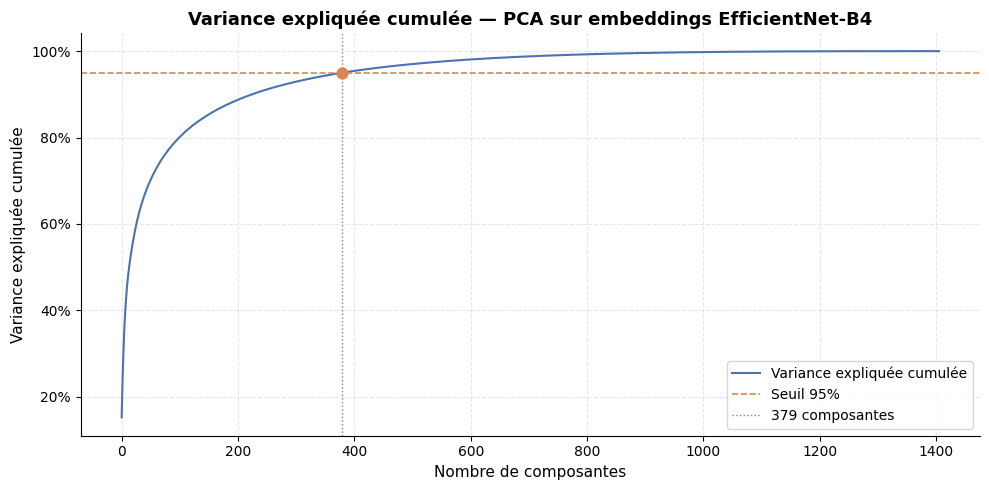

379 dimensions à garder pour conserver 95% de la variance


In [6]:
pcamodel = PCA(n_components=min(X_scaled.shape), random_state=42)
pcamodel.fit(X_scaled)

cumvar = np.cumsum(pcamodel.explained_variance_ratio_)
dim = np.argmax(cumvar > 0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cumvar, color="#4C72B0", linewidth=1.5, label="Variance expliquée cumulée")
ax.axhline(0.95, color="#DD8452", linewidth=1.2, linestyle="--", label="Seuil 95%")
ax.axvline(dim, color="gray", linewidth=1, linestyle=":", label=f"{dim} composantes")
ax.scatter([dim], [cumvar[dim]], color="#DD8452", zorder=5, s=60)

ax.set_title(f"Variance expliquée cumulée — PCA sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composantes", fontsize=11)
ax.set_ylabel("Variance expliquée cumulée", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"{dim} dimensions à garder pour conserver 95% de la variance")

In [7]:
pcamodel = PCA(n_components=dim)
pcamodel.fit(X_scaled)
X_pca = pcamodel.transform(X_scaled)
X_pca.shape

(1406, 379)

# Clustering

In [8]:
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)

In [9]:
gmm.fit(X_pca)
cluster_labels = gmm.predict(X_pca)

In [10]:
# Add cluster labels back to train_df
train_df = train_df.copy()
train_df["cluster"] = cluster_labels

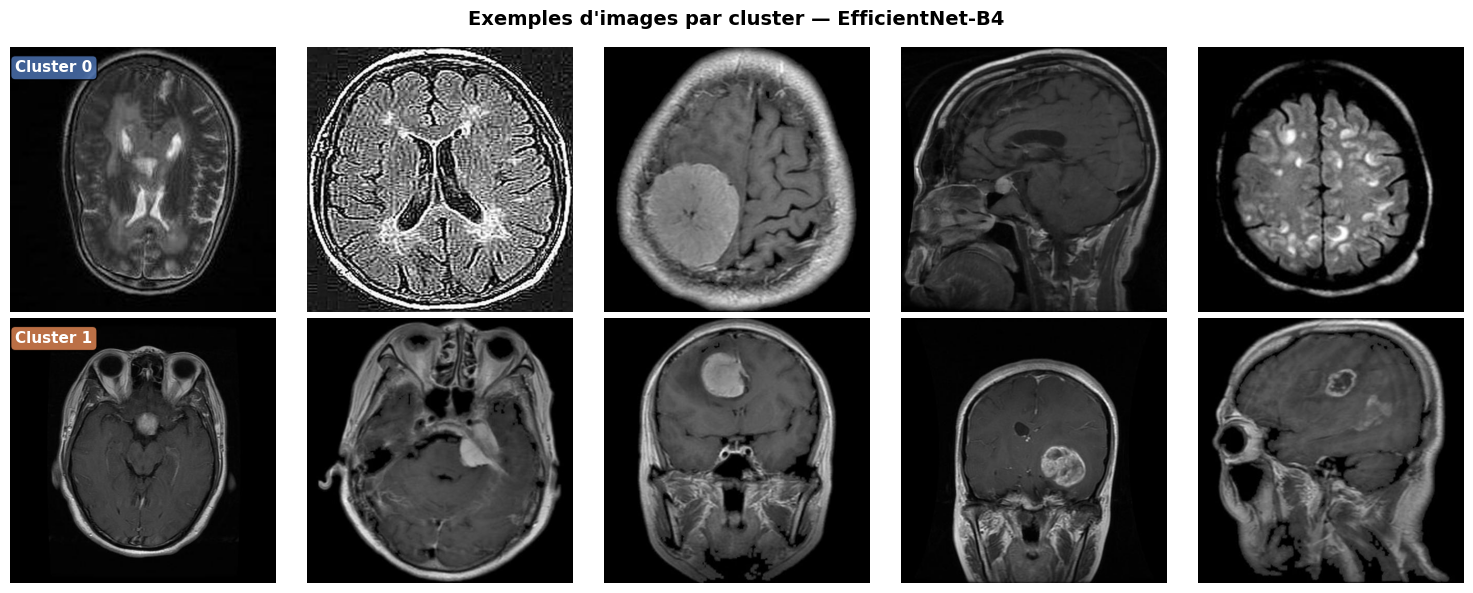

In [11]:
from PIL import Image

CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}
n_samples = 5
clusters = [0, 1]
fig, axes = plt.subplots(len(clusters), n_samples, figsize=(15, 6))
fig.suptitle(f"Exemples d'images par cluster — {modele}", fontsize=14, fontweight="bold")

for row_idx, cluster_id in enumerate(clusters):
    sample_paths = (
        train_df[train_df["cluster"] == cluster_id]["image_path"]
        .sample(n_samples, random_state=21)
        .tolist()
    )
    for col_idx, path in enumerate(sample_paths):
        ax = axes[row_idx][col_idx]
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id}",
        transform=axes[row_idx][0].transAxes,
        fontsize=11, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

In [12]:
sil = silhouette_score(X_pca, cluster_labels)
bic = gmm.bic(X_pca)
aic = gmm.aic(X_pca)

print(f"Silhouette : {sil:.4f}  (plus proche de 1 = meilleur)")
print(f"BIC        : {bic:.1f}  (plus bas = meilleur)")
print(f"AIC        : {aic:.1f}  (plus bas = meilleur)")
print(f"Converged  : {gmm.converged_}  (itérations : {gmm.n_iter_})")

Silhouette : 0.1174  (plus proche de 1 = meilleur)
BIC        : 2409521.2  (plus bas = meilleur)
AIC        : 1649648.0  (plus bas = meilleur)
Converged  : True  (itérations : 3)


# Visualisation

In [13]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

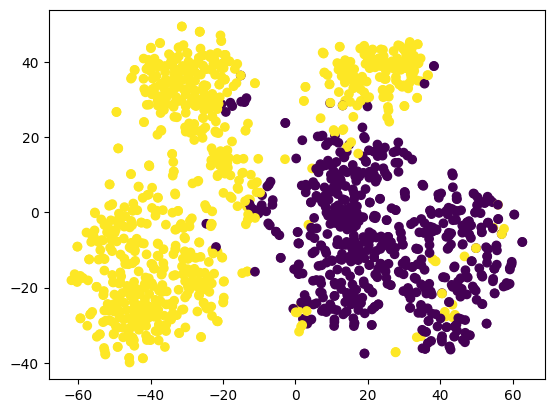

In [14]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels)

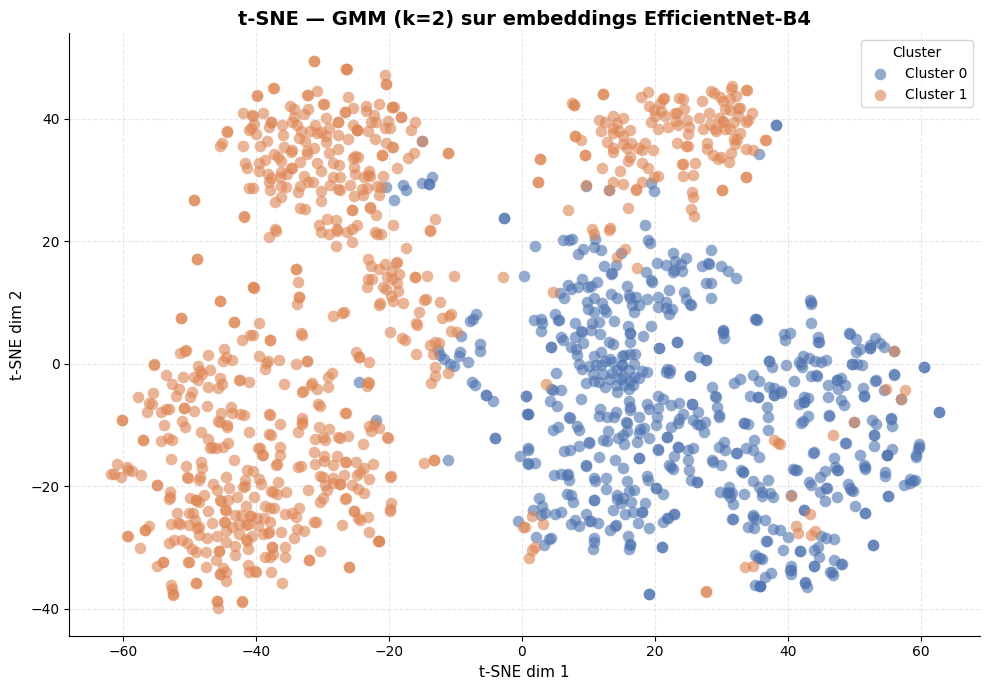

In [15]:
CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}",
        alpha=0.6, s=70, linewidths=0,
    )

ax.set_title(f"t-SNE — GMM (k=2) sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# SCORES

Mapping retenu : cluster 0 → normal, cluster 1 → cancer

  Accuracy   : 0.7900
  Precision  : 0.8085  (cancer=positif)
  Recall     : 0.7600  (cancer=positif)
  F1-score   : 0.7835
  F2-score   : 0.7692  (recall x2)
  ARI        : 0.3297

              precision    recall  f1-score   support

      Normal       0.77      0.82      0.80        50
      Cancer       0.81      0.76      0.78        50

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



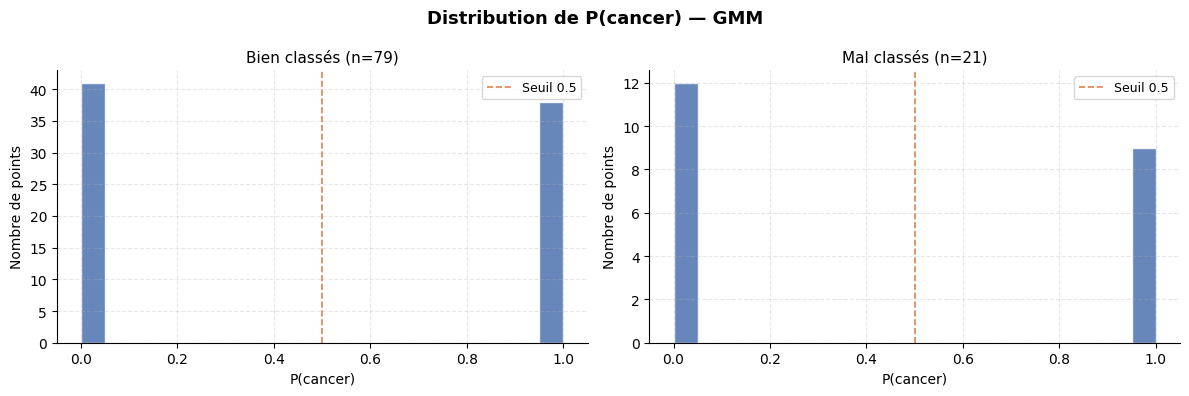

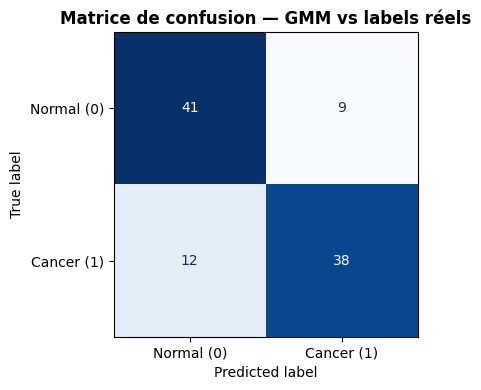

In [16]:
X_test = test_df.drop(columns=["label", "image_path"])
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_test_pca = pcamodel.transform(X_test_scaled)
cluster_pred = gmm.predict(X_test_pca)
proba_pred   = gmm.predict_proba(X_test_pca)   # shape (n, 2)
y_true = test_df["label"].values  # 0=normal, 1=cancer

# ── Alignement des labels ──────────────────────────────────────────────────
acc_direct   = (cluster_pred == y_true).mean()
acc_inverted = (1 - cluster_pred == y_true).mean()

if acc_direct >= acc_inverted:
    aligned_pred = cluster_pred
    cluster_to_class = {0: "normal", 1: "cancer"}
else:
    aligned_pred = 1 - cluster_pred
    cluster_to_class = {0: "cancer", 1: "normal"}

cancer_cluster = [c for c, name in cluster_to_class.items() if name == "cancer"][0]
proba_cancer = proba_pred[:, cancer_cluster]  # P(appartenir au cluster cancer)

ari = adjusted_rand_score(y_true, aligned_pred)
print(f"Mapping retenu : cluster 0 → {cluster_to_class[0]}, cluster 1 → {cluster_to_class[1]}\n")

# ── Métriques ──────────────────────────────────────────────────────────────
print("=" * 45)
print(f"  Accuracy   : {accuracy_score(y_true, aligned_pred):.4f}")
print(f"  Precision  : {precision_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  Recall     : {recall_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  F1-score   : {f1_score(y_true, aligned_pred):.4f}")
print(f"  F2-score   : {fbeta_score(y_true, aligned_pred, beta=2):.4f}  (recall x2)")
print(f"  ARI        : {ari:.4f}")
print("=" * 45)
print()
print(classification_report(y_true, aligned_pred, target_names=["Normal", "Cancer"]))

# ── Distribution des probabilités — bien vs mal classés ───────────────────
correct_mask = aligned_pred == y_true
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de P(cancer) — GMM", fontsize=13, fontweight="bold")

for ax, (label, mask) in zip(axes, [("Bien classés", correct_mask), ("Mal classés", ~correct_mask)]):
    n = mask.sum()
    ax.hist(proba_cancer[mask], bins=20, range=(0, 1), color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="#DD8452", linestyle="--", linewidth=1.2, label="Seuil 0.5")
    ax.set_title(f"{label} (n={n})", fontsize=11)
    ax.set_xlabel("P(cancer)", fontsize=10)
    ax.set_ylabel("Nombre de points", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# ── Matrice de confusion ───────────────────────────────────────────────────
cm = confusion_matrix(y_true, aligned_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Cancer (1)"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matrice de confusion — GMM vs labels réels", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Classification par seuil

Avant l'export des pseudo-labels, on introduit une phase de classification basée sur
la **confiance d'appartenance** à chaque cluster GMM. On calcule les distances euclidiennes
de chaque point aux deux centroïdes `gmm.means_`, puis le ratio :

$$ \text{ratio} = \frac{d_2}{d_1 + d_2} $$

- **ratio proche de 0 ou 1** → point très proche d'un centroïde, cluster confiant
- **ratio proche de 0.5** → point équidistant, appartenance ambiguë

## Classification par seuil — Partie 1 : Exploration

On explore la distribution du ratio et on teste plusieurs seuils symétriques avant de
fixer la valeur définitive en Partie 2.

distances shape : (1406, 2)
ratio range     : [0.3862, 0.6534]  (mean=0.5018)


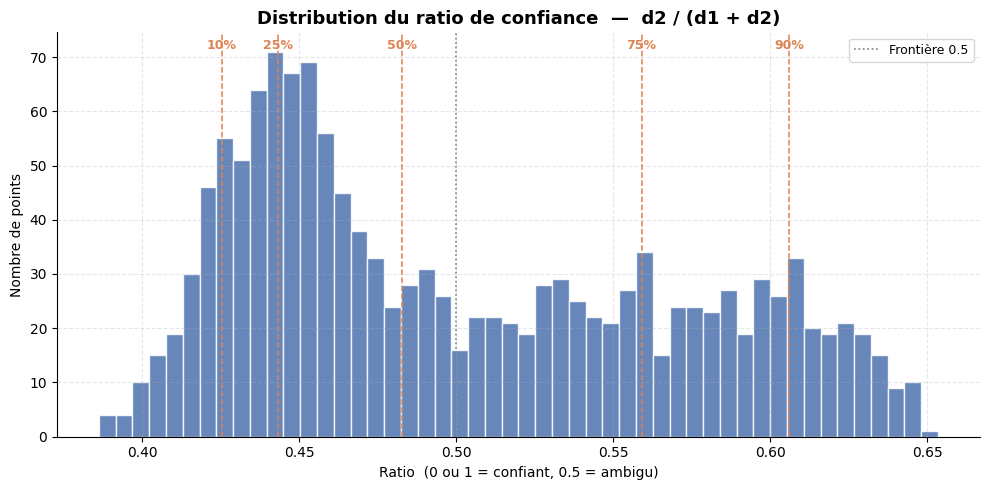


Points ambigus par seuil candidat :

 seuil_bas  seuil_haut  n_confiants  n_ambigus pct_ambigus
      0.20        0.80            0       1406      100.0%
      0.25        0.75            0       1406      100.0%
      0.30        0.70            0       1406      100.0%
      0.40        0.60          187       1219       86.7%
      0.45        0.55          837        569       40.5%


In [20]:
# ── Confidence ratio based on Euclidean distances to GMM centroids ────────
from scipy.spatial.distance import cdist

# Euclidean distance from each PCA-projected point to the two GMM centroids
distances = cdist(X_pca, gmm.means_)  # shape (1406, 2)
d1 = distances[:, 0]
d2 = distances[:, 1]
ratio = d2 / (d1 + d2)  # close to 0 or 1 = confident, close to 0.5 = ambiguous

print(f"distances shape : {distances.shape}")
print(f"ratio range     : [{ratio.min():.4f}, {ratio.max():.4f}]  (mean={ratio.mean():.4f})")

# ── Histogram of the ratio distribution with quantile markers ─────────────
quantile_levels = [0.10, 0.25, 0.50, 0.75, 0.90]
quantiles = np.quantile(ratio, quantile_levels)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ratio, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)

ymax = ax.get_ylim()[1]
for q, level in zip(quantiles, quantile_levels):
    ax.axvline(q, color="#DD8452", linestyle="--", linewidth=1.1)
    ax.text(q, ymax * 0.96, f"{int(level*100)}%", ha="center", fontsize=9,
            color="#DD8452", fontweight="bold")

ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Frontière 0.5")
ax.set_title("Distribution du ratio de confiance  —  d2 / (d1 + d2)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Ratio  (0 ou 1 = confiant, 0.5 = ambigu)")
ax.set_ylabel("Nombre de points")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# ── Candidate symmetric thresholds and % of ambiguous points ──────────────
candidates = [(0.2, 0.8), (0.25, 0.75), (0.3, 0.7), (0.4, 0.6), (0.45, 0.55)]
rows = []
for low, high in candidates:
    ambiguous_mask = (ratio >= low) & (ratio <= high)
    rows.append({
        "seuil_bas"   : low,
        "seuil_haut"  : high,
        "n_confiants" : int((~ambiguous_mask).sum()),
        "n_ambigus"   : int(ambiguous_mask.sum()),
        "pct_ambigus" : f"{ambiguous_mask.mean():.1%}",
    })

seuils_df = pd.DataFrame(rows)
print("\nPoints ambigus par seuil candidat :\n")
print(seuils_df.to_string(index=False))

## Classification par seuil — Partie 2 : Application

On fixe maintenant les bornes `LOW` et `HIGH` et on range chaque point dans l'une
des trois catégories : `cluster_0_confiant`, `cluster_1_confiant`, `ambigu`.

> Valeurs par défaut : `LOW=0.3`, `HIGH=0.7`. À ajuster selon la Partie 1.

In [18]:
# ── Apply the chosen threshold and categorize each point ─────────────────
# Adjust LOW / HIGH after inspecting Part 1 (histogram + candidate table).
LOW, HIGH = 0.45, 0.55

confidence_category = np.full(len(ratio), "ambigu", dtype=object)
confidence_category[ratio <= LOW]  = "cluster_1_confiant"   # ratio ~0 → close to centroid 1
confidence_category[ratio >= HIGH] = "cluster_0_confiant"   # ratio ~1 → close to centroid 0

is_confident = (ratio <= LOW) | (ratio >= HIGH)

# ── Summary by category ───────────────────────────────────────────────────
n_total = len(ratio)
summary = (
    pd.Series(confidence_category)
    .value_counts()
    .rename_axis("categorie")
    .reset_index(name="n")
)
summary["pct"] = (summary["n"] / n_total * 100).round(1).astype(str) + " %"

print(f"Seuils appliqués : LOW={LOW} / HIGH={HIGH}")
print(f"Total            : {n_total} points")
print(f"  Confiants      : {int(is_confident.sum())} ({is_confident.mean():.1%})")
print(f"  Ambigus        : {int((~is_confident).sum())} ({(~is_confident).mean():.1%})\n")
print(summary.to_string(index=False))

Seuils appliqués : LOW=0.45 / HIGH=0.55
Total            : 1406 points
  Confiants      : 837 (59.5%)
  Ambigus        : 569 (40.5%)

         categorie   n    pct
            ambigu 569 40.5 %
cluster_1_confiant 435 30.9 %
cluster_0_confiant 402 28.6 %


## Classification par seuil — Partie 3 : Comparaison t-SNE

On compare visuellement la t-SNE originale (toutes les 1406 images) et la t-SNE filtrée
(uniquement les points confiants) pour juger si la séparation devient plus propre.

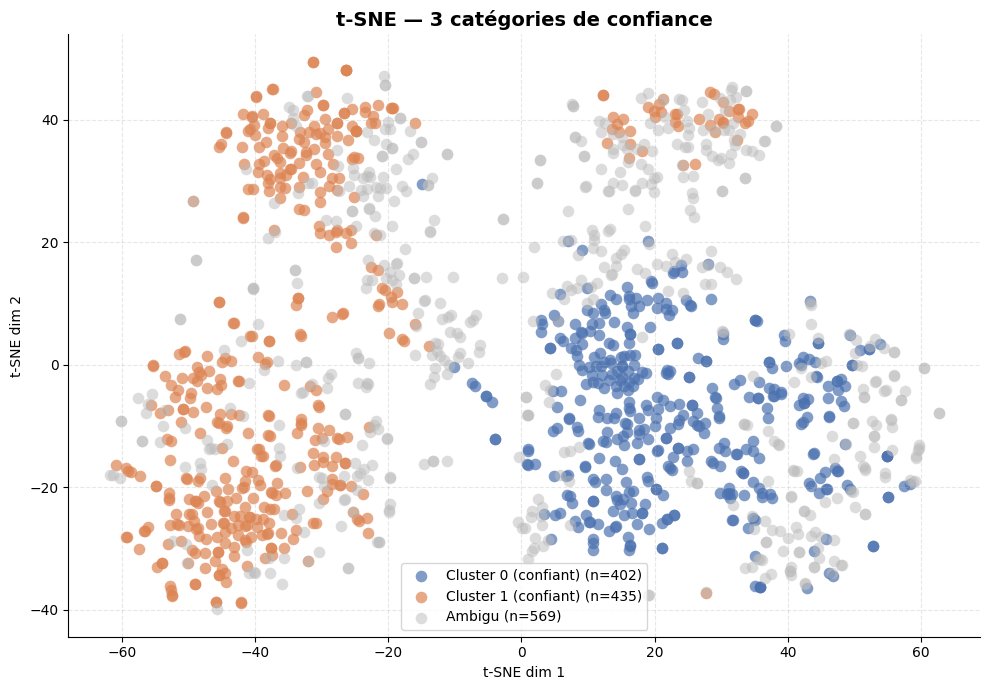

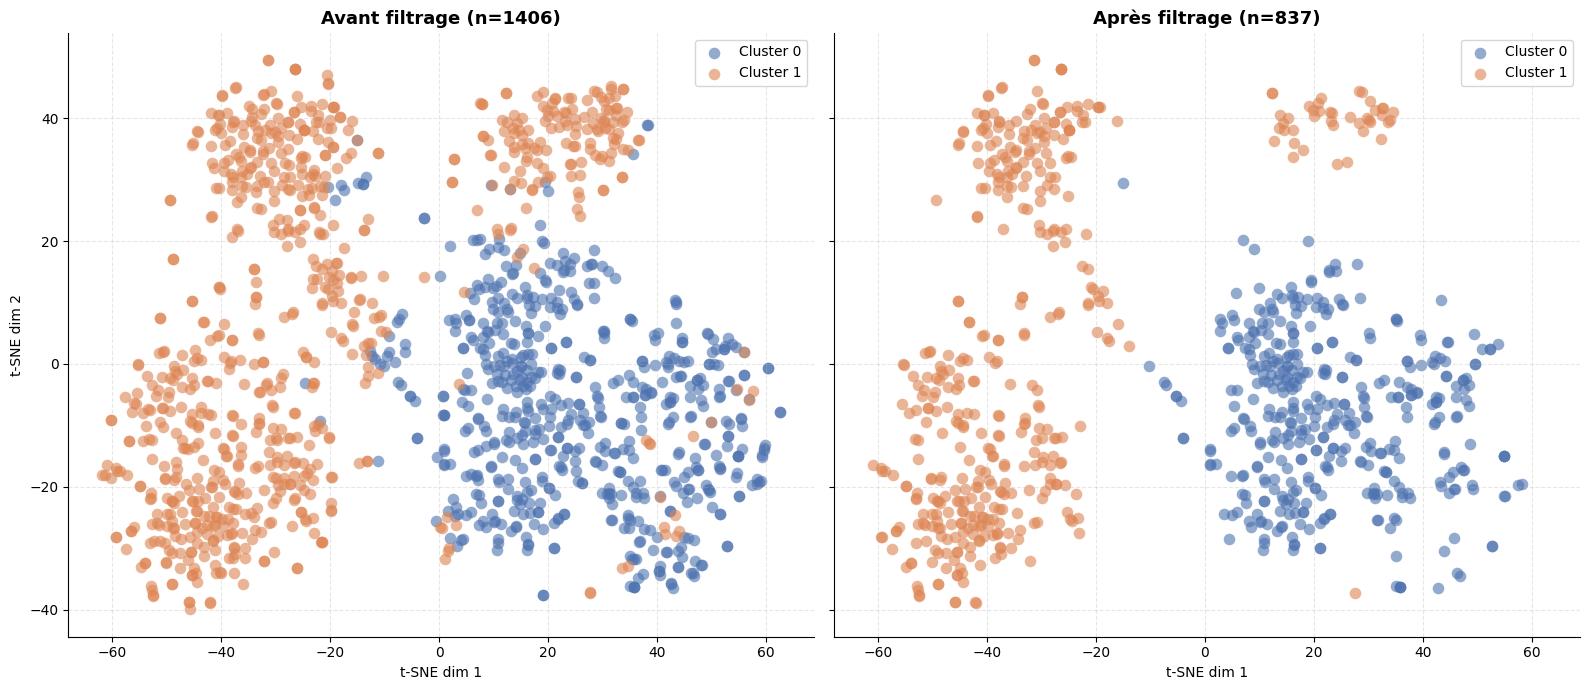

In [19]:
# ── Plot 1 : t-SNE with 3 confidence categories on a single plot ──────────
CATEGORY_STYLES = {
    "cluster_0_confiant": {"color": CLUSTER_COLORS[0], "label": "Cluster 0 (confiant)", "alpha": 0.7},
    "cluster_1_confiant": {"color": CLUSTER_COLORS[1], "label": "Cluster 1 (confiant)", "alpha": 0.7},
    "ambigu":             {"color": "#BBBBBB",         "label": "Ambigu",               "alpha": 0.5},
}

fig, ax = plt.subplots(figsize=(10, 7))
for category, style in CATEGORY_STYLES.items():
    mask = confidence_category == category
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=style["color"], label=f'{style["label"]} (n={mask.sum()})',
        alpha=style["alpha"], s=70, linewidths=0,
    )
ax.set_title("t-SNE — 3 catégories de confiance", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# ── Plot 2 : side-by-side comparison — original vs filtered ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Left : original t-SNE, all points colored by cluster
for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}", alpha=0.6, s=70, linewidths=0,
    )
axes[0].set_title(f"Avant filtrage (n={len(cluster_labels)})", fontsize=13, fontweight="bold")
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.3)

# Right : filtered t-SNE, confident points only
for cluster_id, color in CLUSTER_COLORS.items():
    mask = (cluster_labels == cluster_id) & is_confident
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}", alpha=0.6, s=70, linewidths=0,
    )
axes[1].set_title(f"Après filtrage (n={int(is_confident.sum())})", fontsize=13, fontweight="bold")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

# Extractions

In [24]:
# ── Pseudo-labels GMM — uniquement points confiants (seuil 0.45 / 0.55) ───
from scipy.spatial.distance import cdist

proba_train = gmm.predict_proba(X_pca)  # shape (1406, 2)

# Confidence via Euclidean distance ratio to the two GMM centroids
distances = cdist(X_pca, gmm.means_)
ratio = distances[:, 1] / (distances[:, 0] + distances[:, 1])

# Keep points outside the ambiguous band [LOW, HIGH]
LOW, HIGH = 0.45, 0.55
confident_mask = (ratio < LOW) | (ratio > HIGH)

pseudo_df = pd.DataFrame({
    "image_path"   : train_df["image_path"].values,
    "label"        : [1 if cluster_to_class[c] == "cancer" else 0 for c in cluster_labels],
    "proba_cancer" : proba_train[:, cancer_cluster].round(4),
    "proba_normal" : proba_train[:, 1 - cancer_cluster].round(4),
    "ratio"        : ratio.round(4),
})

n_total = len(pseudo_df)
pseudo_df = pseudo_df.loc[confident_mask].reset_index(drop=True)
n_kept = len(pseudo_df)

print(f"Total initial    : {n_total}")
print(f"Ambigus écartés  : {n_total - n_kept}  (ratio dans [{LOW}, {HIGH}])")
print(f"Conservés        : {n_kept}  ({n_kept/n_total:.1%})")
print(f"  pseudo-cancer (1) : {(pseudo_df['label'] == 1).sum()}")
print(f"  pseudo-normal (0) : {(pseudo_df['label'] == 0).sum()}\n")

out_path = Path("pseudo_labels_gmm_v2.csv")
pseudo_df.to_csv(out_path, index=False)
print(f"Sauvegardé → {out_path}")

pseudo_df


Total initial    : 1406
Ambigus écartés  : 569  (ratio dans [0.45, 0.55])
Conservés        : 837  (59.5%)
  pseudo-cancer (1) : 435
  pseudo-normal (0) : 402

Sauvegardé → pseudo_labels_gmm_v2.csv


,image_path,label,proba_cancer,proba_normal,ratio
0,data\sans_label\001b158a-7af8-451e-bf31-3a9116...,1,1.0,0.0,0.4433
1,data\sans_label\00455a62-f79f-4072-9a23-4951e7...,0,0.0,1.0,0.6337
2,data\sans_label\005d9a37-8894-4eb5-8367-1015d4...,1,1.0,0.0,0.4334
3,data\sans_label\009eac4a-c951-4da9-852a-b32e9c...,1,1.0,0.0,0.4415
4,data\sans_label\00e9e198-79de-47ab-9f4e-7b7615...,1,1.0,0.0,0.4174
...,...,...,...,...,...
832,data\sans_label\fcf1c2ea-fe58-495e-b7b9-c30ee1...,0,0.0,1.0,0.6337
833,data\sans_label\fe4454fb-f164-40a8-b7ec-dca240...,0,0.0,1.0,0.6026
834,data\sans_label\fe4fdff6-284e-41f9-a55d-817258...,1,1.0,0.0,0.4282
835,data\sans_label\fe83bb10-600a-40fa-b7a9-13e79e...,1,1.0,0.0,0.4332


In [ ]:
# ── Test set avec vrais labels ─────────────────────────────────────────────
test_export_df = pd.DataFrame({
    "image_path"   : test_df["image_path"].values,
    "label" : test_df["label"].values,   # vrais labels : 1=cancer, 0=normal
    "proba_cancer" : proba_pred[:, cancer_cluster].round(4),
    "proba_normal" : proba_pred[:, 1 - cancer_cluster].round(4),
})

print(f"Total : {len(test_export_df)} images")
print(f"  cancer (1) : {(test_export_df['label'] == 1).sum()}")
print(f"  normal (0) : {(test_export_df['label'] == 0).sum()}\n")

out_path_test = Path("true_labels_test.csv")
test_export_df.to_csv(out_path_test, index=False)
print(f"Sauvegardé → {out_path_test}")

test_export_df.head(10)

Total : 100 images
  cancer (1) : 50
  normal (0) : 50

Sauvegardé → true_labels_test.csv


,image_path,label,proba_cancer,proba_normal
0,data\avec_labels\cancer\05340cd4-3bb2-459d-993...,1,1.0,0.0
1,data\avec_labels\cancer\0c6f3641-60d9-4a76-abe...,1,0.0,1.0
2,data\avec_labels\cancer\0f718241-8f63-4b55-81c...,1,1.0,0.0
3,data\avec_labels\cancer\11a7a426-4806-401e-98b...,1,1.0,0.0
4,data\avec_labels\cancer\1c043dbb-4623-4769-8e5...,1,1.0,0.0
5,data\avec_labels\cancer\27149ff6-8363-4942-a72...,1,1.0,0.0
6,data\avec_labels\cancer\2b810835-844c-49ff-b0f...,1,1.0,0.0
7,data\avec_labels\cancer\2d662cc1-509b-4657-a20...,1,1.0,0.0
8,data\avec_labels\cancer\2fa551e9-5b85-44f6-ab7...,1,1.0,0.0
9,data\avec_labels\cancer\3c3d07cb-ec2a-43b0-b8a...,1,1.0,0.0
